# The Approach

- the simplest way I can think of for connecting to postgres is the same when you connect in fastapi, but instead of using the asyncio and an async engine, we will use sqlalchemy and connect directly using psycopg

In [50]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

load_dotenv()

# I have my postgres instance password in my .env file
password = os.getenv("POSTGRES_PASSWORD")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [51]:
# making a connection with the postgres instance with psycopg
connection_url = URL.create(
    drivername="postgresql+psycopg",
    username="postgres",
    password=password,
    host="127.0.0.1",
    port=5432,
    database="adventure_works"
)

# make an engine using sqlalchemy and now we can push this in all our pd.read_sql queries
engine = create_engine(connection_url)

In [52]:
pd.read_sql("SELECT current_database(), current_user;", engine)

,current_database,current_user
0,adventure_works,postgres


- it worked

In [53]:
monthly_sales = pd.read_sql("""
SELECT *
FROM analytics.monthly_sales_growth
ORDER BY order_month;
""", engine)

product_rankings = pd.read_sql("""
SELECT *
FROM analytics.product_rankings;
""", engine)

territory_rankings = pd.read_sql("""
SELECT *
FROM analytics.territory_rankings;
""", engine)

customer_performance = pd.read_sql("""
SELECT *
FROM analytics.customer_performance;
""", engine)

category_performance = pd.read_sql("""
SELECT *
FROM analytics.category_performance;
""", engine)

salesperson_performance = pd.read_sql("""
SELECT *
FROM analytics.salesperson_performance;
""", engine)

inventory_health = pd.read_sql("""
SELECT *
FROM analytics.inventory_health;
""", engine)

executive_kpis = pd.read_sql("""
SELECT *
FROM analytics.executive_kpi_summary;
""", engine)

In [54]:
monthly_sales.head()

,order_month,total_orders,total_items_sold,revenue,cost,profit,previous_month_revenue,revenue_change,revenue_growth_percent
0,2022-05-01,47,829,5.177374e+05,5.082531e+05,9484.339100,NaN,NaN,NaN
1,2022-06-01,217,2195,2.001279e+06,1.789988e+06,211291.030738,5.177374e+05,1.483542e+06,286.54
2,2022-07-01,215,1667,1.668510e+06,1.441331e+06,227179.704976,2.001279e+06,-3.327685e+05,-16.63
3,2022-08-01,189,1391,1.326138e+06,1.140312e+06,185826.079570,1.668510e+06,-3.423724e+05,-20.52
4,2022-09-01,250,3123,2.836410e+06,2.608610e+06,227799.924404,1.326138e+06,1.510272e+06,113.88


- ok everything is working

---

## Typecasting the main columns I need for the visualizations

In [55]:
monthly_sales["order_month"] = pd.to_datetime(monthly_sales["order_month"])

money_cols = ["revenue", "cost", "profit"]
for col in money_cols:
    if col in monthly_sales.columns:
        monthly_sales[col] = pd.to_numeric(monthly_sales[col])

for df in [product_rankings, territory_rankings, customer_performance, category_performance, salesperson_performance]:
    for col in ["revenue", "cost", "profit"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col])




In [56]:
from pathlib import Path
from matplotlib.ticker import FuncFormatter

CHART_DIR = Path("charts")
CHART_DIR.mkdir(exist_ok=True)

def money_millions(x, pos):
    return f"${x/1_000_000:.1f}M"

def money_fmt(x, pos):
    if abs(x) >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    if abs(x) >= 1_000:
        return f"${x/1_000:.0f}K"
    return f"${x:.0f}"

money_formatter = FuncFormatter(money_fmt)

### Chart 1: Revenue Trend

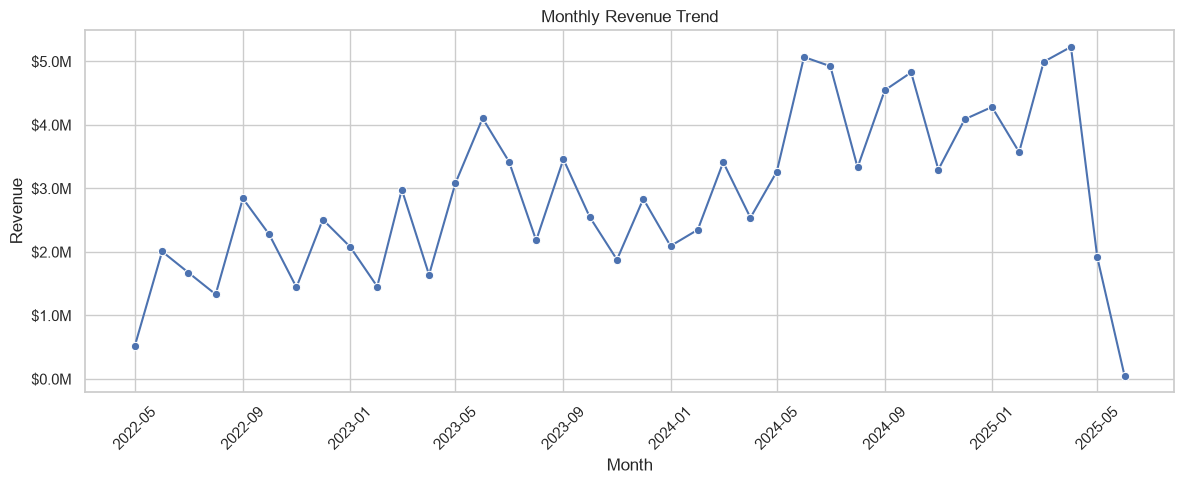

In [57]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="order_month", y="revenue", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(FuncFormatter(money_millions))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(CHART_DIR / "01_revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

- Revenue changes month to month, but the overall trend shows several strong sales periods, especially later in the timeline. This helps management identify seasonal patterns and months where sales performance increased or dropped.

### Chart 2: Monthly Revenue Growth

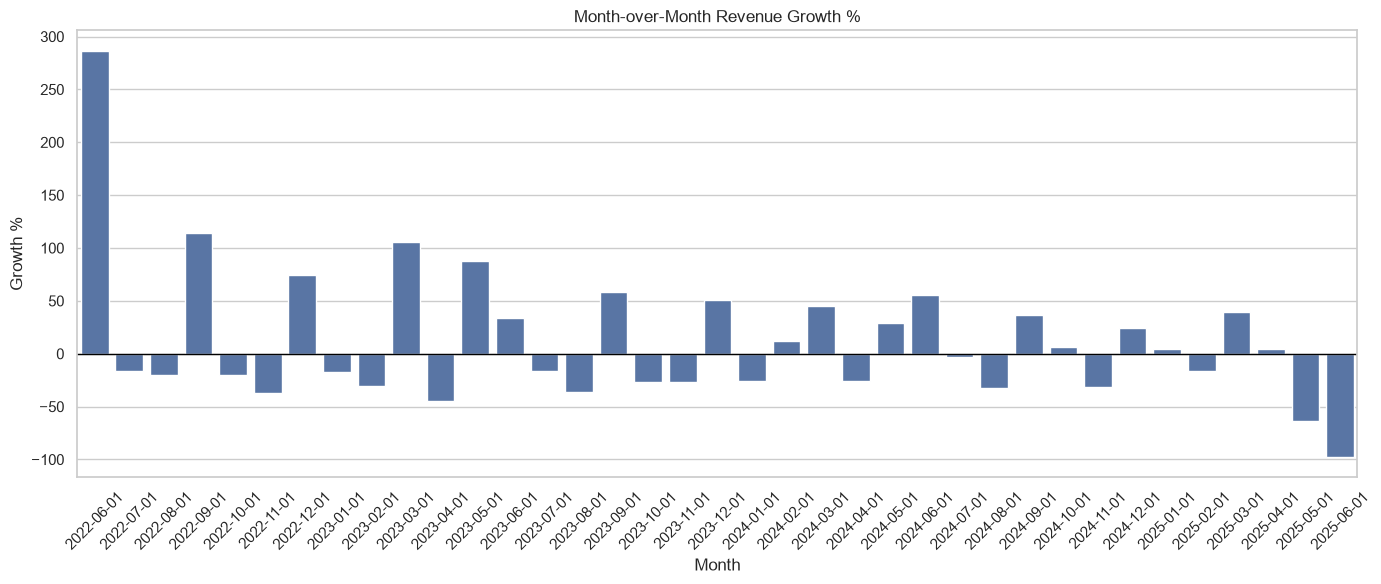

In [58]:
growth_data = monthly_sales.dropna(subset=["revenue_growth_percent"])

plt.figure(figsize=(14, 6))
sns.barplot(data=growth_data, x="order_month", y="revenue_growth_percent")
plt.title("Month-over-Month Revenue Growth %")
plt.xlabel("Month")
plt.ylabel("Growth %")
plt.xticks(rotation=45)
plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.savefig(CHART_DIR / "02_monthly_revenue_growth.png", dpi=300, bbox_inches="tight")
plt.show()

- Month-over-month growth shows how unstable or strong revenue movement is compared to the previous month. Positive bars mean revenue increased, while negative bars show months where revenue declined.

### Chart 3: Revenue by Territories

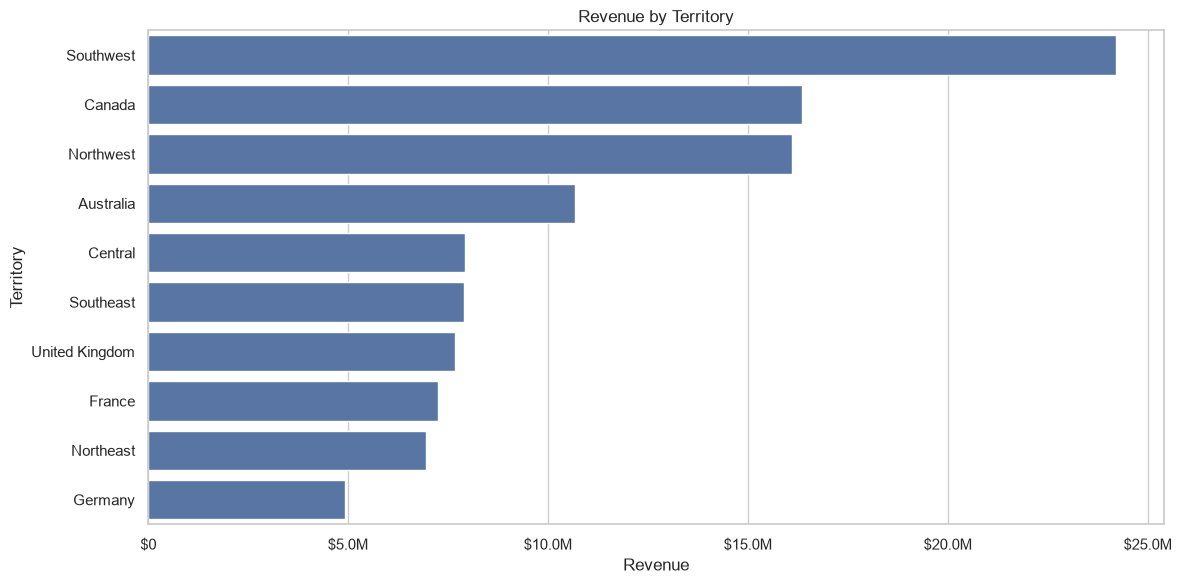

In [59]:
territory_plot = territory_rankings.sort_values("revenue", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=territory_plot, x="revenue", y="territory_name")
plt.title("Revenue by Territory")
plt.xlabel("Revenue")
plt.ylabel("Territory")
plt.gca().xaxis.set_major_formatter(money_formatter)
plt.tight_layout()
plt.savefig(CHART_DIR / "03_revenue_by_territory.png", dpi=300, bbox_inches="tight")
plt.show()

- Southwest generates the highest revenue among all territories, followed by Canada and Northwest. This shows which regions are contributing most to sales and which regions may need more attention.

### Chart 4: Customer Segments

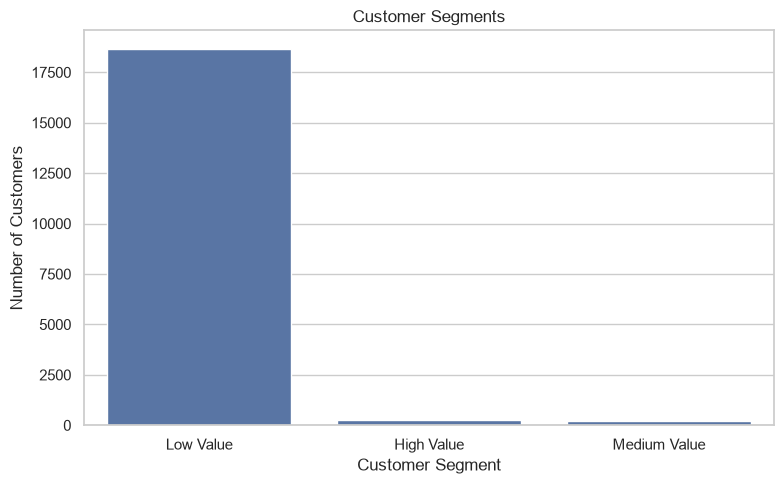

In [60]:
segment_counts = customer_performance["customer_segment"].value_counts().reset_index()
segment_counts.columns = ["customer_segment", "customer_count"]

plt.figure(figsize=(8, 5))
sns.barplot(data=segment_counts, x="customer_segment", y="customer_count")
plt.title("Customer Segments")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_customer_segments.png", dpi=300, bbox_inches="tight")
plt.show()

- Most customers fall into the Low Value segment, while High Value and Medium Value customers are much smaller groups. This suggests that a small number of customers contribute much more spending and may be important for retention.

### Chart 5: Top Products

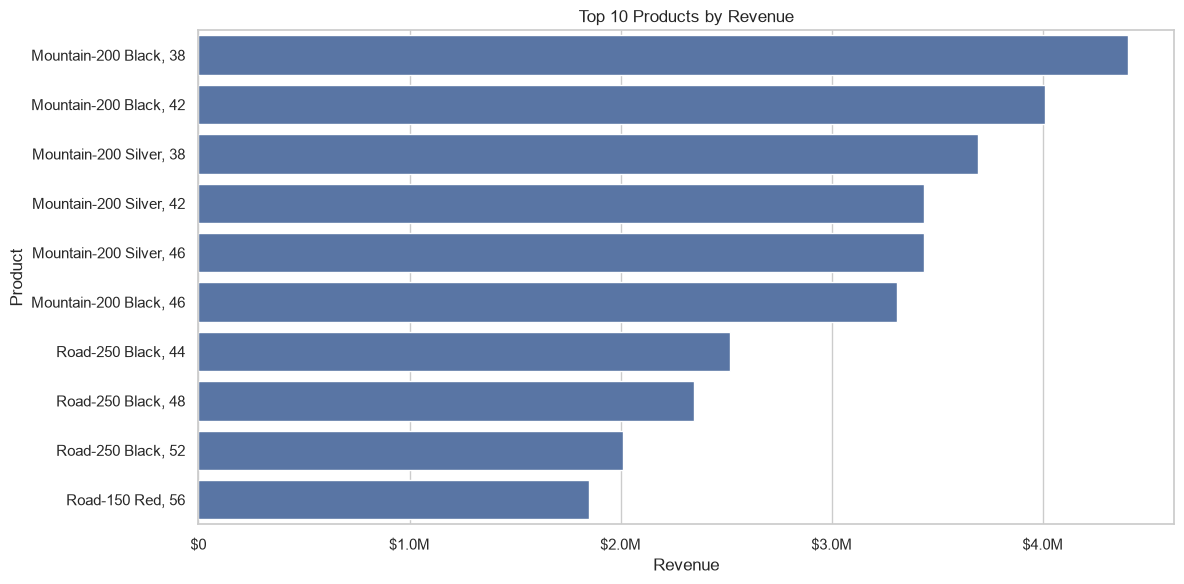

In [61]:
top_products = product_rankings.sort_values("revenue_rank").head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, x="revenue", y="product_name")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.gca().xaxis.set_major_formatter(money_formatter)
plt.tight_layout()
plt.savefig(CHART_DIR / "05_top_products_by_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

- Mountain bikes provide a ton more revenue as compared to the rest, the top 6 are all mountain bikes. Not much else to find out from this chart to be honest

### Chart 6: Revenue by Category

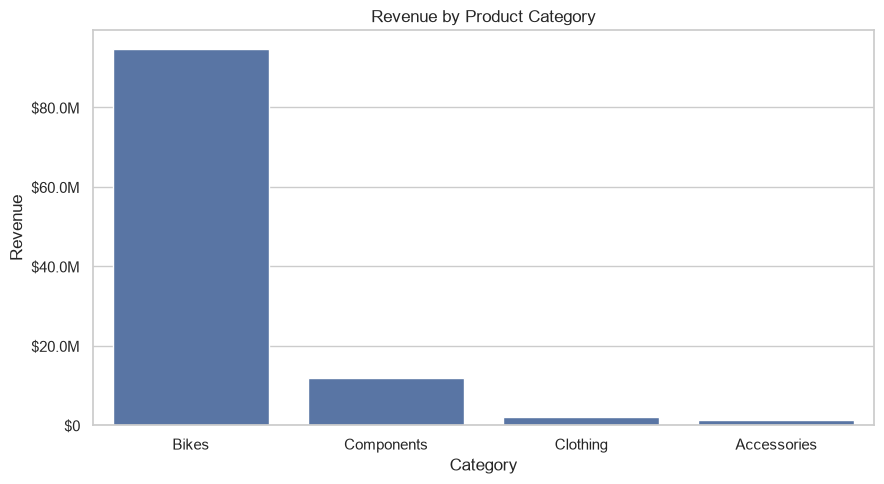

In [62]:
category_plot = category_performance.sort_values("revenue", ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(data=category_plot, x="category_name", y="revenue")
plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.gca().yaxis.set_major_formatter(money_formatter)
plt.tight_layout()
plt.savefig(CHART_DIR / "06_category_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

- Bikes generate far more revenue than Components, Clothing, and Accessories. The business is heavily dependent on the Bikes category, so changes in bike demand would strongly affect overall revenue.

### Chart 7: Salesperson Performance

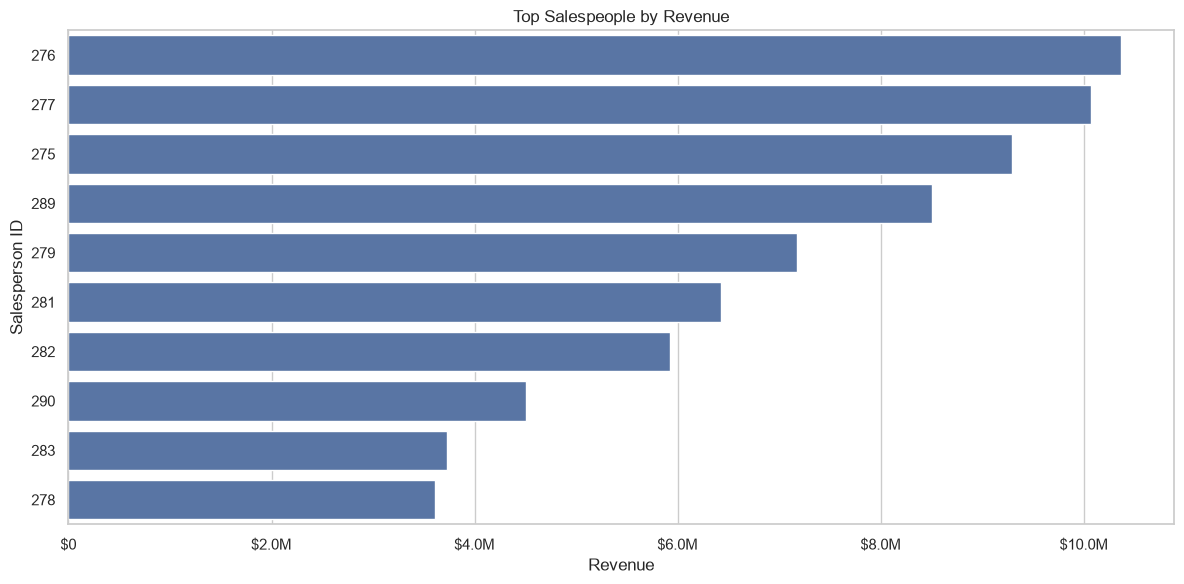

In [63]:
salesperson_plot = salesperson_performance.sort_values("revenue", ascending=False).head(10).copy()
salesperson_plot["salespersonid"] = salesperson_plot["salespersonid"].astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(data=salesperson_plot, x="revenue", y="salespersonid")
plt.title("Top Salespeople by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Salesperson ID")
plt.gca().xaxis.set_major_formatter(money_formatter)
plt.tight_layout()
plt.savefig(CHART_DIR / "07_salespeople_by_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

- This chart compares salespeople based on generated revenue. It helps identify the strongest sales contributors and can support performance reviews or sales planning.

### Chart 8: Inventory Status

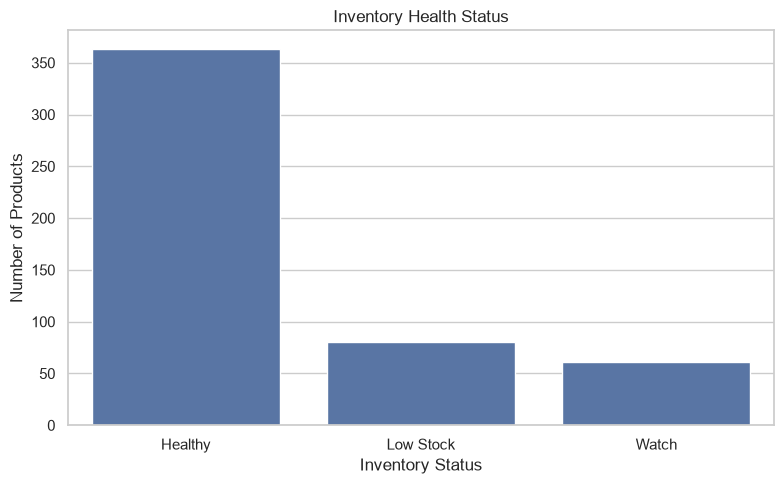

In [64]:
inventory_counts = inventory_health["inventory_status"].value_counts().reset_index()
inventory_counts.columns = ["inventory_status", "product_count"]

plt.figure(figsize=(8, 5))
sns.barplot(data=inventory_counts, x="inventory_status", y="product_count")
plt.title("Inventory Health Status")
plt.xlabel("Inventory Status")
plt.ylabel("Number of Products")
plt.tight_layout()
plt.savefig(CHART_DIR / "08_inventory_status.png", dpi=300, bbox_inches="tight")
plt.show()

- Most products are in Healthy inventory status, but there are still products marked Low Stock or Watch. These products should be reviewed so the company can avoid future stock shortages.

---
---
---

- I'm going to get codex to print the metrics used to make recommendations in the readme so its easy for you to check that the readme.md isn't just making  things up, this is not really part of the submission I guess

#### Supporting Evidence for Task 6

Before writing the final opportunities, risks, and recommendations, I am pulling the supporting numbers directly from the analytics views. This is basically the proof section so the recommendations are backed by SQL output and not just guessed.


In [65]:
evidence_executive_kpis = pd.read_sql("""
SELECT *
FROM analytics.executive_kpi_summary;
""", engine)

evidence_category = pd.read_sql("""
SELECT category_name, revenue, profit
FROM analytics.category_performance
ORDER BY revenue DESC;
""", engine)

evidence_territory = pd.read_sql("""
SELECT territory_name, revenue, profit, revenue_rank, profit_rank
FROM analytics.territory_rankings
ORDER BY revenue_rank;
""", engine)

evidence_customer_segments = pd.read_sql("""
SELECT customer_segment, COUNT(*) AS customers, SUM(revenue) AS revenue
FROM analytics.customer_performance
GROUP BY customer_segment
ORDER BY revenue DESC;
""", engine)

evidence_inventory = pd.read_sql("""
SELECT inventory_status, COUNT(*) AS products
FROM analytics.inventory_health
GROUP BY inventory_status
ORDER BY products DESC;
""", engine)

evidence_top_products = pd.read_sql("""
SELECT product_name, revenue, profit, revenue_rank
FROM analytics.product_rankings
ORDER BY revenue_rank
LIMIT 10;
""", engine)

display(Markdown("### Executive KPI Summary"))
display(evidence_executive_kpis)

display(Markdown("### Category Performance"))
display(evidence_category)

display(Markdown("### Territory Rankings"))
display(evidence_territory)

display(Markdown("### Customer Segment Revenue"))
display(evidence_customer_segments)

display(Markdown("### Inventory Status Counts"))
display(evidence_inventory)

display(Markdown("### Top 10 Products by Revenue"))
display(evidence_top_products)


### Executive KPI Summary

,total_revenue,total_cost,total_profit,total_orders,total_items_sold,total_customers,high_value_customers,store_customers,individual_customers,low_stock_products,watch_products,healthy_products
0,1.098464e+08,1.004745e+08,9.371904e+06,31465.0,274914.0,19119,244,0,19119,80,61,363


### Category Performance

,category_name,revenue,profit
0,Bikes,9.465117e+07,7.936394e+06
1,Components,1.180259e+07,4.902332e+05
2,Clothing,2.120543e+06,3.088822e+05
3,Accessories,1.272073e+06,6.363943e+05


### Territory Rankings

...

,customer_segment,customers,revenue
0,High Value,244,7.150974e+07
1,Low Value,18642,2.971685e+07
2,Medium Value,233,8.619788e+06


### Inventory Status Counts

,inventory_status,products
0,Healthy,363
1,Low Stock,80
2,Watch,61


### Top 10 Products by Revenue

,product_name,revenue,profit,revenue_rank
0,"Mountain-200 Black, 38",4.400593e+06,673444.470300,1
1,"Mountain-200 Black, 42",4.009495e+06,674216.578641,2
2,"Mountain-200 Silver, 38",3.693678e+06,663784.942272,3
3,"Mountain-200 Silver, 42",3.438479e+06,611084.897423,4
4,"Mountain-200 Silver, 46",3.434257e+06,629644.129928,5
5,"Mountain-200 Black, 46",3.309673e+06,666740.692608,6
6,"Road-250 Black, 44",2.516857e+06,-36367.136882,7
7,"Road-250 Black, 48",2.347656e+06,18343.999254,8
8,"Road-250 Black, 52",2.012448e+06,76537.639500,9
9,"Road-150 Red, 56",1.847819e+06,406079.279200,10
